# Origins of replication pre-analysis

From the raw MNase:
- Compute the total occupancy, origin occupancy (small fragments), and non origin occupancy (mostly nucleosomal).
- Compute the peak position of the small origin occupancy location.
- Plot the distribution of the total occupancies and determine a threshold to remove low coverage origins
- Plot the distribution of the proportion of small fragment reads to determine a threshold in which we do not identify an origin footprint.
- Create a column that labels the origins as having called footprints in our dataset.
- Save the constructed dataframe.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [137]:
from pipeline.precompute_origin_analysis import OriginFootprintAnalysis

window = 3000
origin_analysis = OriginFootprintAnalysis(window_size=window)

In [144]:
# Generate all the summary data at once (this may take some time)
small_fragments_data, composite_data = \
    origin_analysis.generate_summary_histogram_data(debug=False)

Generating summary histogram data for all timepoints and replicates...
Processing replicate 1...
  Processing chromosome 1 (21 origins) - 00:00:00.001
  Processing chromosome 2 (61 origins) - 00:00:06.704
  Processing chromosome 3 (31 origins) - 00:00:31.439
  Processing chromosome 4 (88 origins) - 00:00:41.926
  Processing chromosome 5 (33 origins) - 00:01:27.231
  Processing chromosome 6 (22 origins) - 00:01:42.697
  Processing chromosome 7 (63 origins) - 00:01:50.894
  Processing chromosome 8 (42 origins) - 00:02:22.799
  Processing chromosome 9 (38 origins) - 00:02:39.573
  Processing chromosome 10 (43 origins) - 00:02:53.632
  Processing chromosome 11 (42 origins) - 00:03:13.720
  Processing chromosome 12 (68 origins) - 00:03:32.899
  Processing chromosome 13 (56 origins) - 00:04:18.183
  Processing chromosome 14 (51 origins) - 00:04:45.445
  Processing chromosome 15 (67 origins) - 00:05:07.726
  Processing chromosome 16 (72 origins) - 00:05:41.088
Processing replicate 2...
  Proc

In [145]:
sorted_idx = (origins.footprint_class == 'g1_and_g2_footprint').sort_values(ascending=False).index
sorted_origins = origins.loc[sorted_idx]

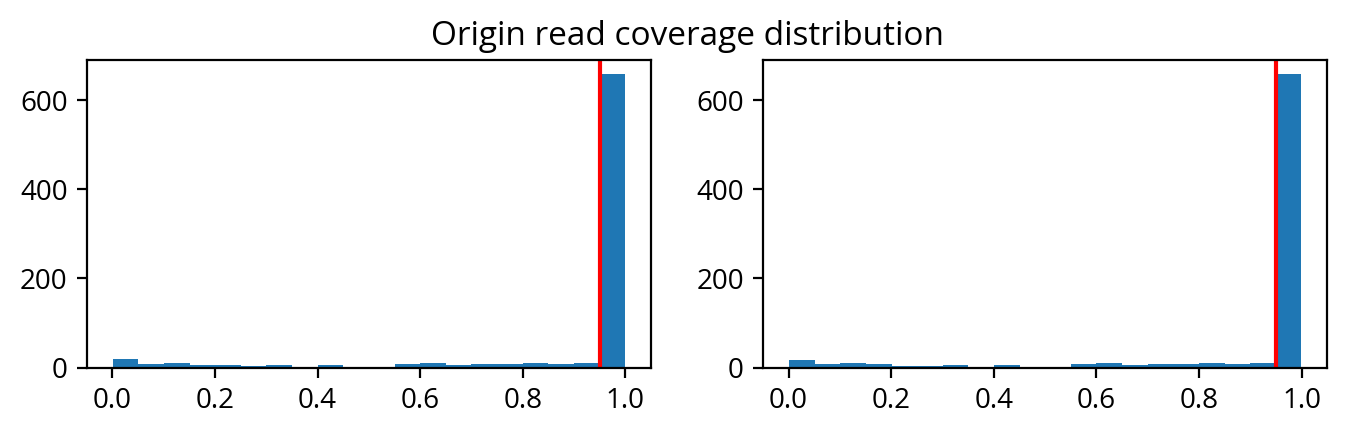

In [146]:
origin_analysis.plot_origin_read_coverage()

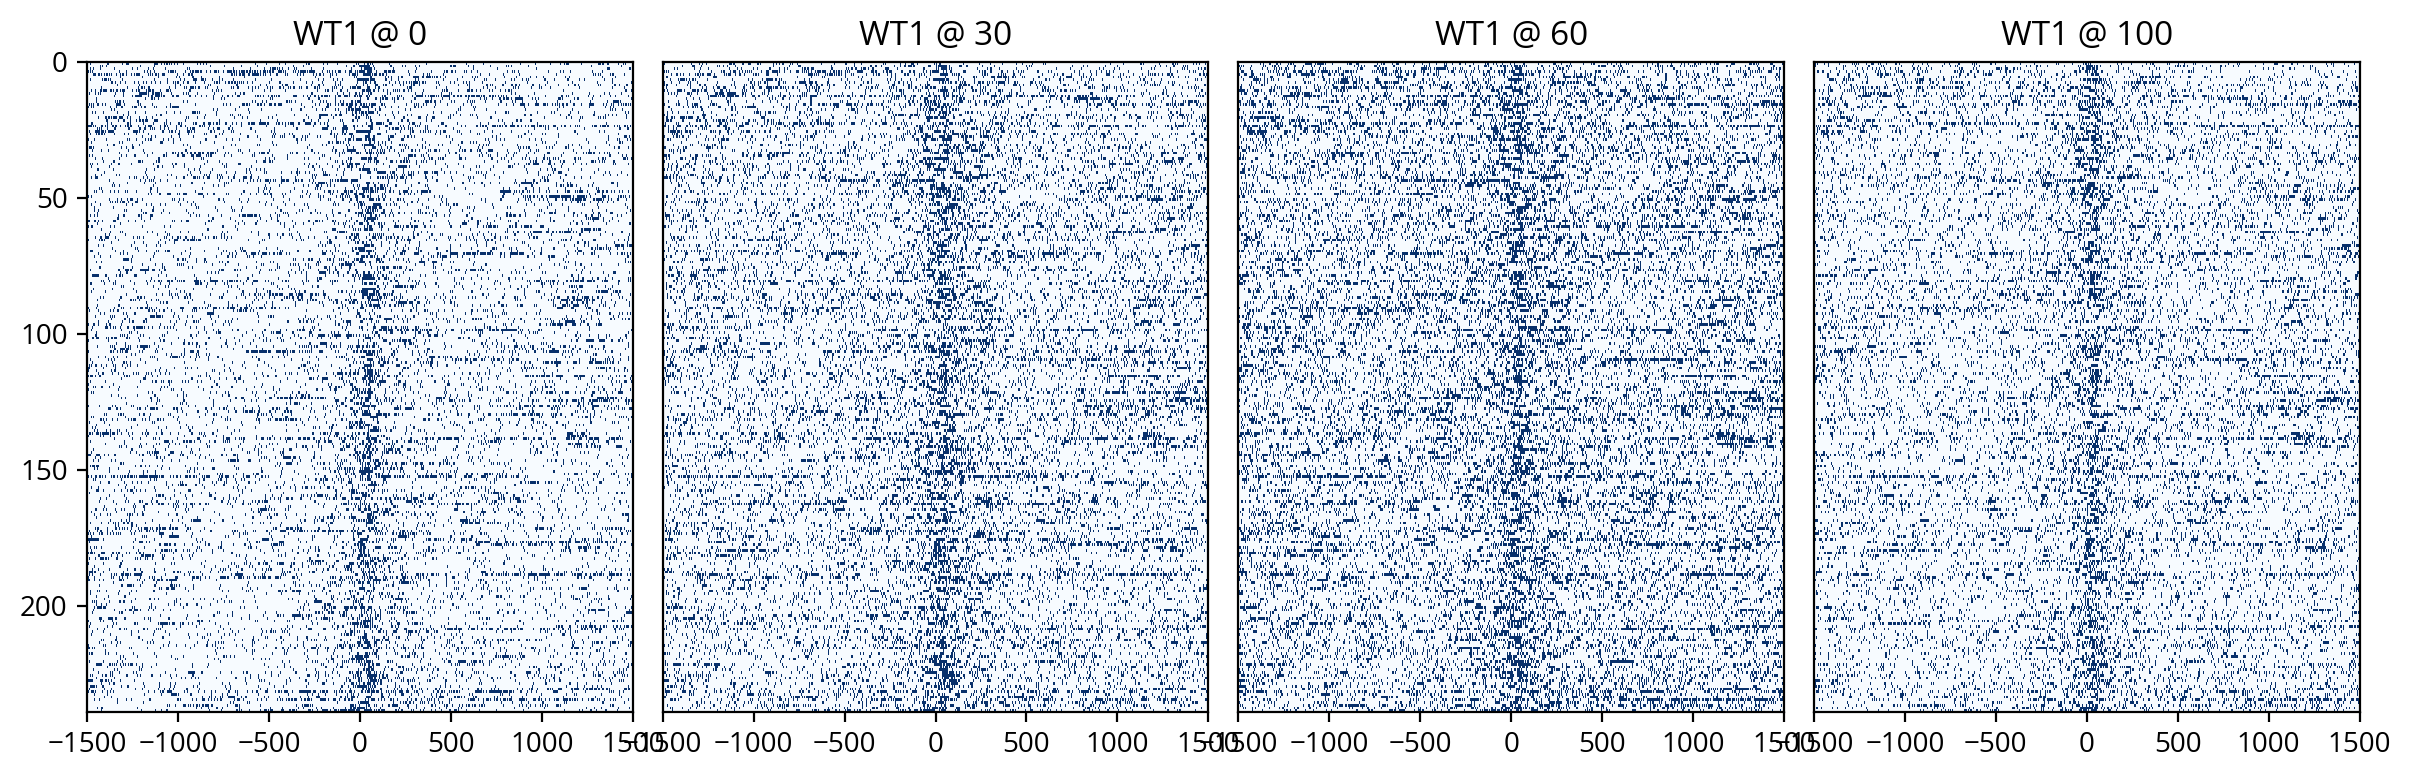

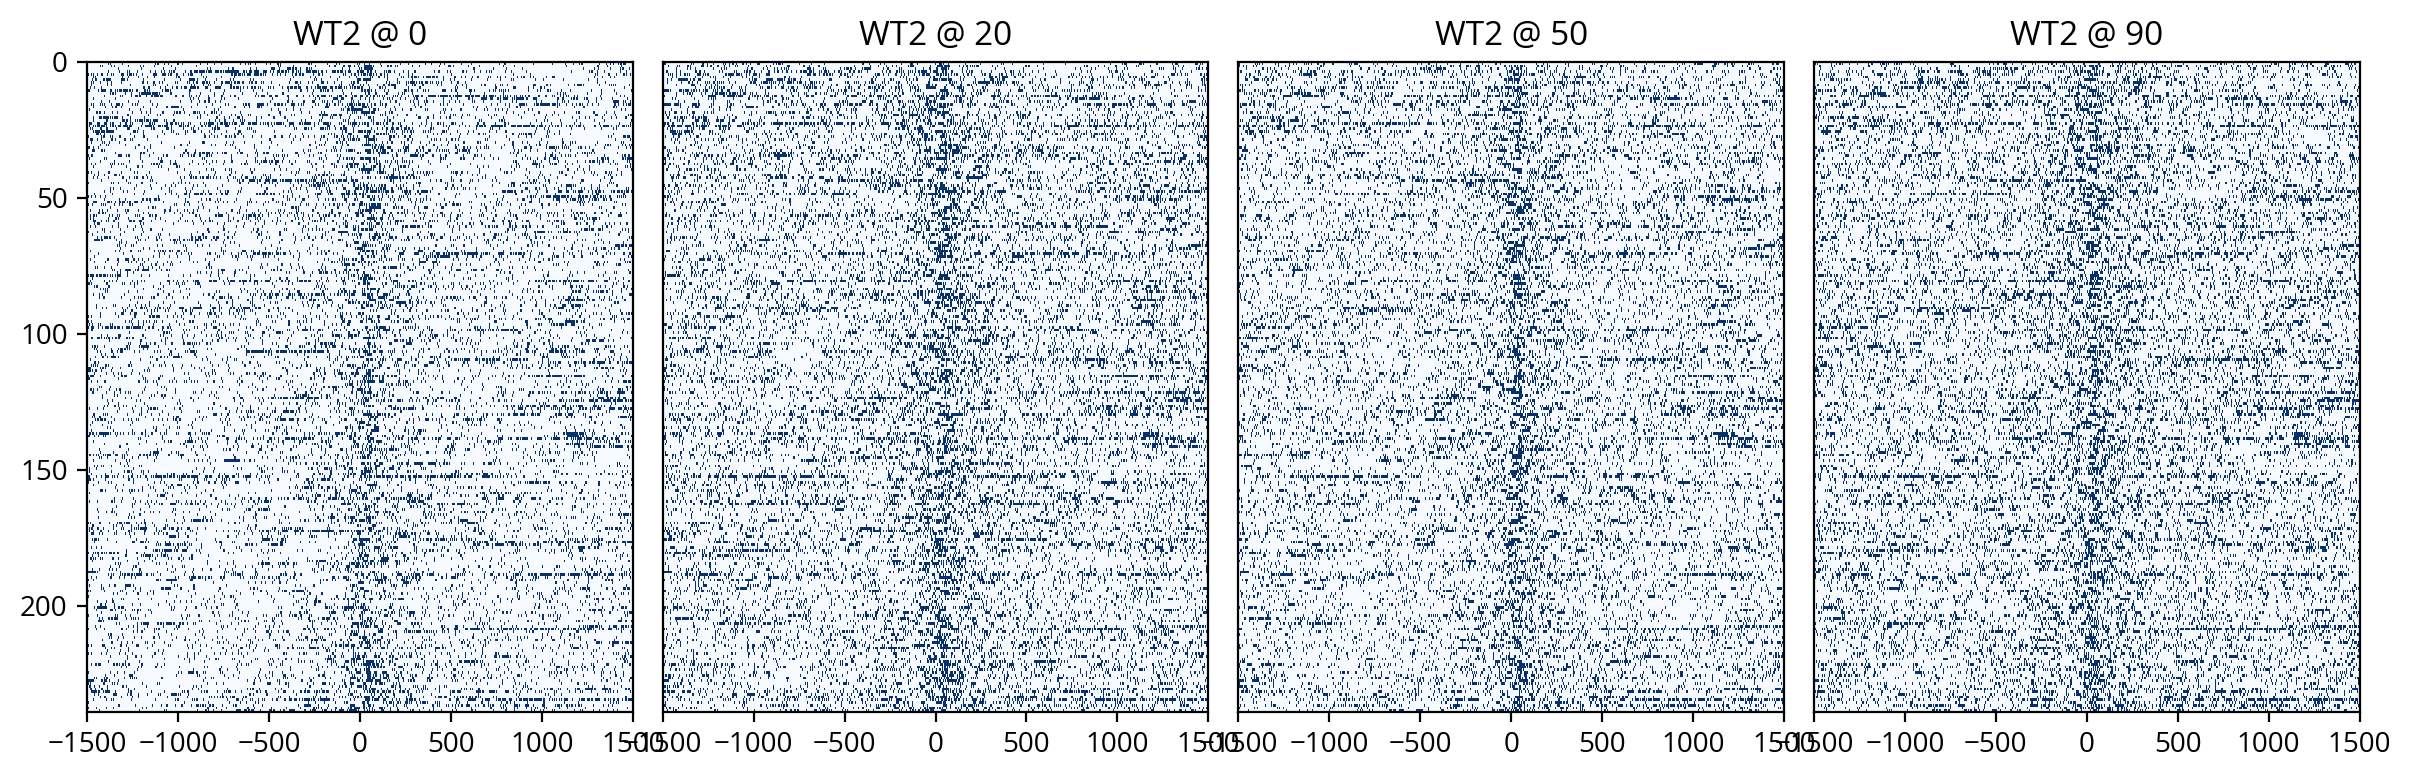

In [147]:
fig = origin_analysis.plot_timecourse_heatmaps(1, [0, 30, 60, 100], sorted_origins)
fig = origin_analysis.plot_timecourse_heatmaps(2, [0, 20, 50, 90], sorted_origins)

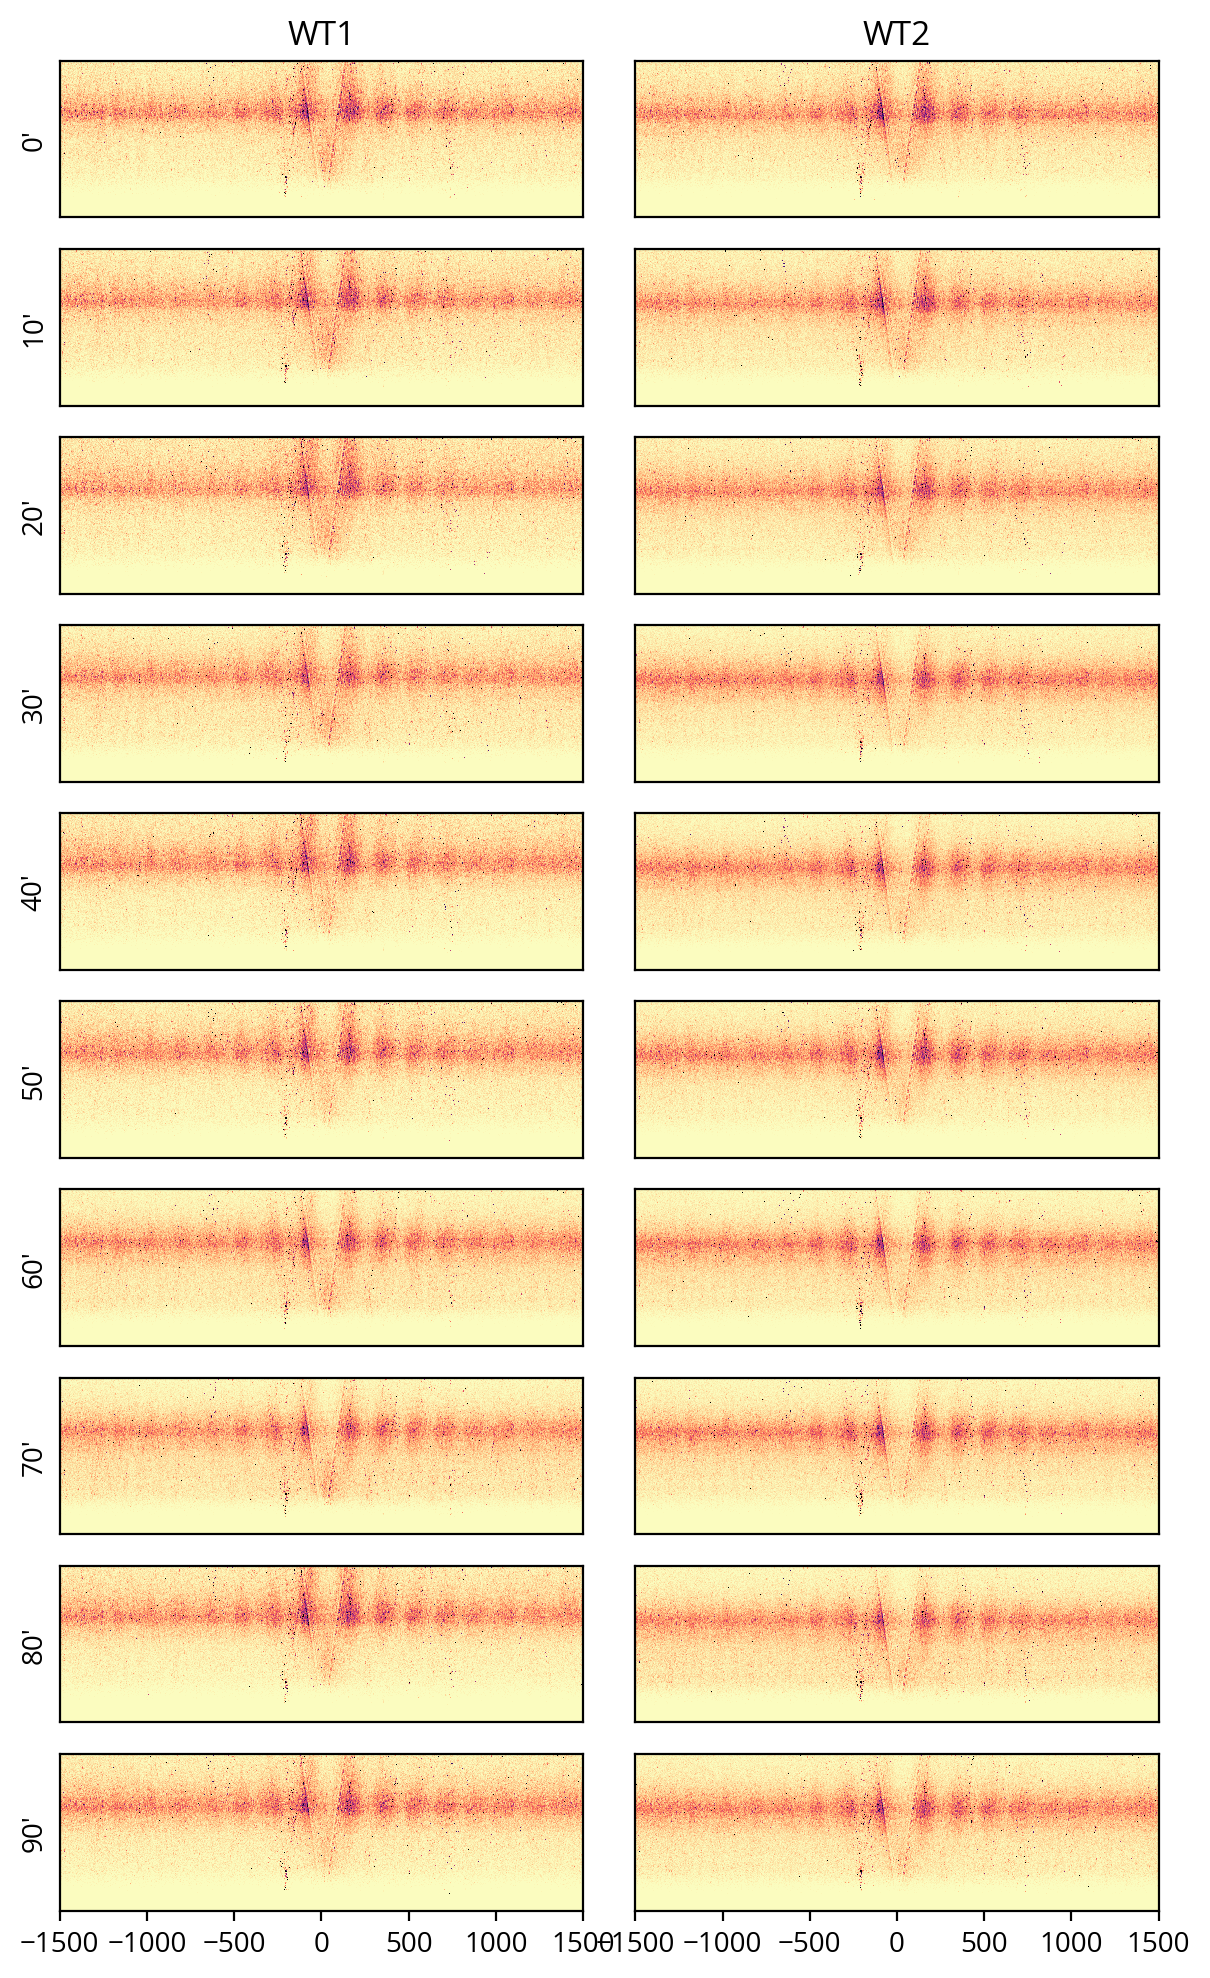

In [168]:
fig = origin_analysis.plot_composite_histograms([1, 2], [0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
                                          max_value=10)

In [ ]:
# Switch ideas, deconvolve a few good origin examples

